<a href="https://colab.research.google.com/github/MrT4ttoo/GestionInformacion/blob/main/Laboratorio_Titanic_Instrucciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Análisis del Dataset Titanic


**Duración:** 30 minutos | **Herramientas:** pandas, matplotlib, seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

Librerías importadas correctamente. Se usará pandas para manipulación de datos,
matplotlib y seaborn para visualización.

### ── PARTE 1: CARGA Y EXPLORACIÓN (10 min) ──


In [ ]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado: 891 filas, 12 columnas


El dataset Titanic se cargó correctamente desde el archivo local.
Contiene 891 filas y 12 columnas, cada fila representa un pasajero del Titanic.

In [ ]:
# 1.2 Primeras 5 filas
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Se observan las primeras 5 filas del dataset. Las columnas incluyen datos del pasajero
como nombre, edad, sexo, clase, tarifa y si sobrevivió o no.

In [ ]:
# 1.3 Información general del DataFrame (tipos de datos y valores no nulos)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


La mayoría de columnas tienen 891 valores no nulos. Se detectan valores faltantes
en Age, Cabin y Embarked desde esta vista. Los tipos de datos mezclan int64, float64 y object.

In [ ]:
# 1.4 Estadísticas descriptivas de columnas numéricas
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Las estadísticas muestran que la edad promedio es ~29.7 años (con solo 714 registros válidos),
la tarifa media es ~32 USD con alta dispersión, y la tasa de supervivencia general es ~38%.

In [ ]:
# 1.5 Dimensiones del dataset
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 891, Columnas: 12


El dataset tiene 891 filas y 12 columnas. Cada fila es un pasajero y cada columna
una variable registrada sobre ese pasajero.

In [ ]:
# 1.6 Conteo de valores nulos por columna
nulos = df.isnull().sum()
print(nulos[nulos > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


Las columnas con valores nulos son:
- Age: 177 nulos (~20%) → requiere imputación antes de modelar
- Cabin: 687 nulos (~77%) → columna poco confiable, puede descartarse
- Embarked: 2 nulos (~0.2%) → se pueden imputar con la moda (S)

### ── PARTE 2: ESTADÍSTICAS (10 min) ──


In [ ]:
# 2.1 Edad promedio por clase
edad_por_clase = df.groupby('Pclass')['Age'].mean()
print(edad_por_clase)

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


La edad promedio varía notablemente entre clases:
- Clase 1: ~38.2 años (pasajeros más adultos y adinerados)
- Clase 2: ~29.9 años
- Clase 3: ~25.1 años (pasajeros más jóvenes, inmigrantes en su mayoría)
Hay una tendencia clara: a mayor clase social, mayor edad promedio.

In [ ]:
# 2.2 Tasa de supervivencia por puerto de embarque
tasa_supervivencia = df.groupby('Embarked')['Survived'].mean()
print(tasa_supervivencia)

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


Los pasajeros embarcados en Cherbourg (C) tuvieron la mayor tasa de supervivencia (~55%), seguidos por Queenstown (Q) (~39%) y Southampton (S) (~34%). Esto se explica en parte porque en Cherbourg abordó una mayor proporción de pasajeros de primera clase.

In [ ]:
# 2.3 Pasajero más joven y más viejo
mas_joven = df.loc[df['Age'].idxmin(), 'Name']
mas_viejo = df.loc[df['Age'].idxmax(), 'Name']

print('Más joven:', mas_joven)
print('Más viejo:', mas_viejo)

Más joven: Thomas, Master. Assad Alexander
Más viejo: Barkworth, Mr. Algernon Henry Wilson


Se usó .idxmin() e .idxmax() sobre la columna Age para obtener el índice de la fila
con el valor mínimo y máximo, luego df.loc[...,'Name'] para extraer el nombre.
- El pasajero más joven tenía 0.42 años (un bebé).
- El pasajero más viejo tenía 80 años.

### ── PARTE 3: VISUALIZACIÓN (10 min) ──


## Parte 3: Visualización
Objetivos:
1. Crear un histograma de tarifas (Fare)
2. Crear un gráfico de barras de supervivencia por sexo
3. Crear un boxplot de edad por clase

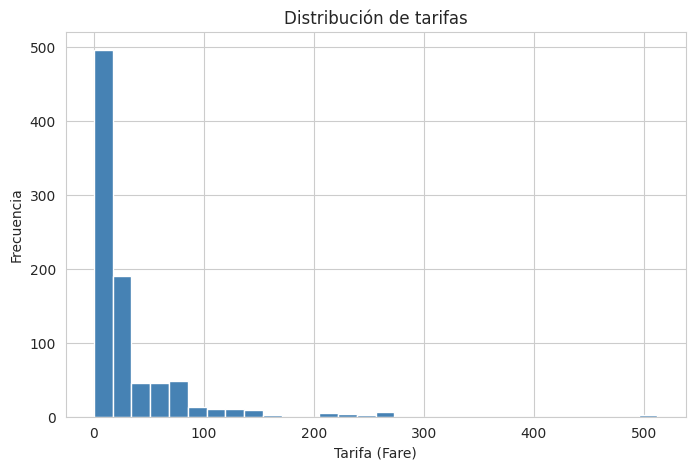

In [ ]:
# 3.1 Histograma de Fare
plt.figure(figsize=(8, 5))
plt.hist(df['Fare'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribución de tarifas')
plt.xlabel('Tarifa (Fare)')
plt.ylabel('Frecuencia')
plt.show()

La distribución de tarifas es fuertemente sesgada a la derecha (right-skewed):
la mayoría de pasajeros pagó menos de 50 USD, mientras que un pequeño grupo
de primera clase pagó tarifas muy altas (hasta ~512 USD).

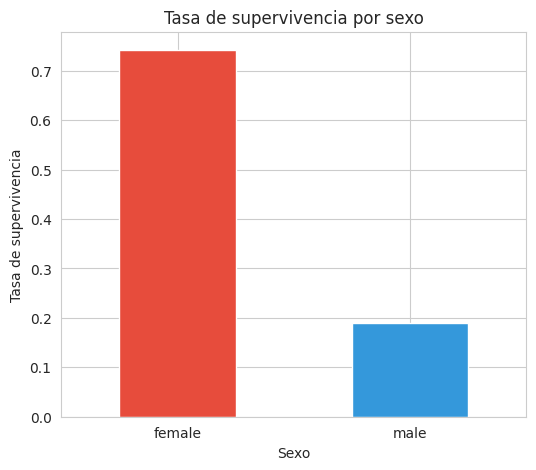

In [ ]:
# 3.2 Tasa de supervivencia por sexo
plt.figure(figsize=(6, 5))
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['#e74c3c', '#3498db'])
plt.title('Tasa de supervivencia por sexo')
plt.xlabel('Sexo')
plt.ylabel('Tasa de supervivencia')
plt.xticks(rotation=0)
plt.show()

Las mujeres sobrevivieron a una tasa de ~74% frente a solo ~19% en los hombres.
Esto refleja la política de evacuación "mujeres y niños primero" aplicada durante el hundimiento.
La diferencia es drástica y convierte al sexo en la variable más predictiva del dataset.

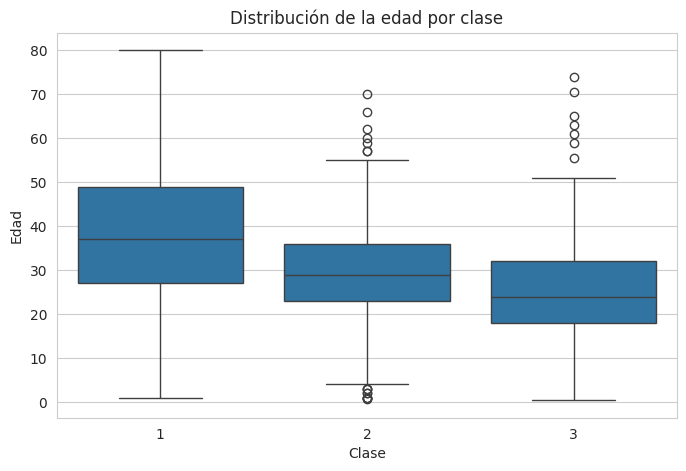

In [ ]:
# 3.3 Boxplot de Age por Pclass
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title('Distribución de la edad por clase')
plt.xlabel('Clase')
plt.ylabel('Edad')
plt.show()

La primera clase concentra pasajeros de mayor edad y con mayor dispersión.
La tercera clase agrupa pasajeros más jóvenes con menor variabilidad.
Los outliers en todas las clases muestran presencia de niños y adultos mayores en todas las categorías.

## Conclusiones

1. El dataset tiene **891 filas y 12 columnas**.
2. Las columnas con valores nulos son: **Age** (~20%), **Cabin** (~77%) y **Embarked** (2 registros).
3. La edad promedio varía por clase: Clase 1 ≈ 38 años | Clase 2 ≈ 30 años | Clase 3 ≈ 25 años.
4. Los pasajeros embarcados en **Cherbourg (C)** tuvieron la mayor tasa de supervivencia (~55%).
5. El pasajero más joven tenía **0.42 años** y el más viejo **80 años**.
6. Las variables más relacionadas con la supervivencia son: **Sex**, **Pclass** y **Fare**.
   El sexo es el predictor más fuerte: las mujeres sobrevivieron a una tasa ~4 veces mayor.